In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression


df = pd.read_csv("train.csv")
df.drop("id",axis = 1,inplace=True)

In [3]:
categorical_cols = ["gender", "stress_level","academic_work_impact"]

numerical_cols = []

for col in df.columns:
    if col not in categorical_cols:
        numerical_cols.append(col)
        plt.show()

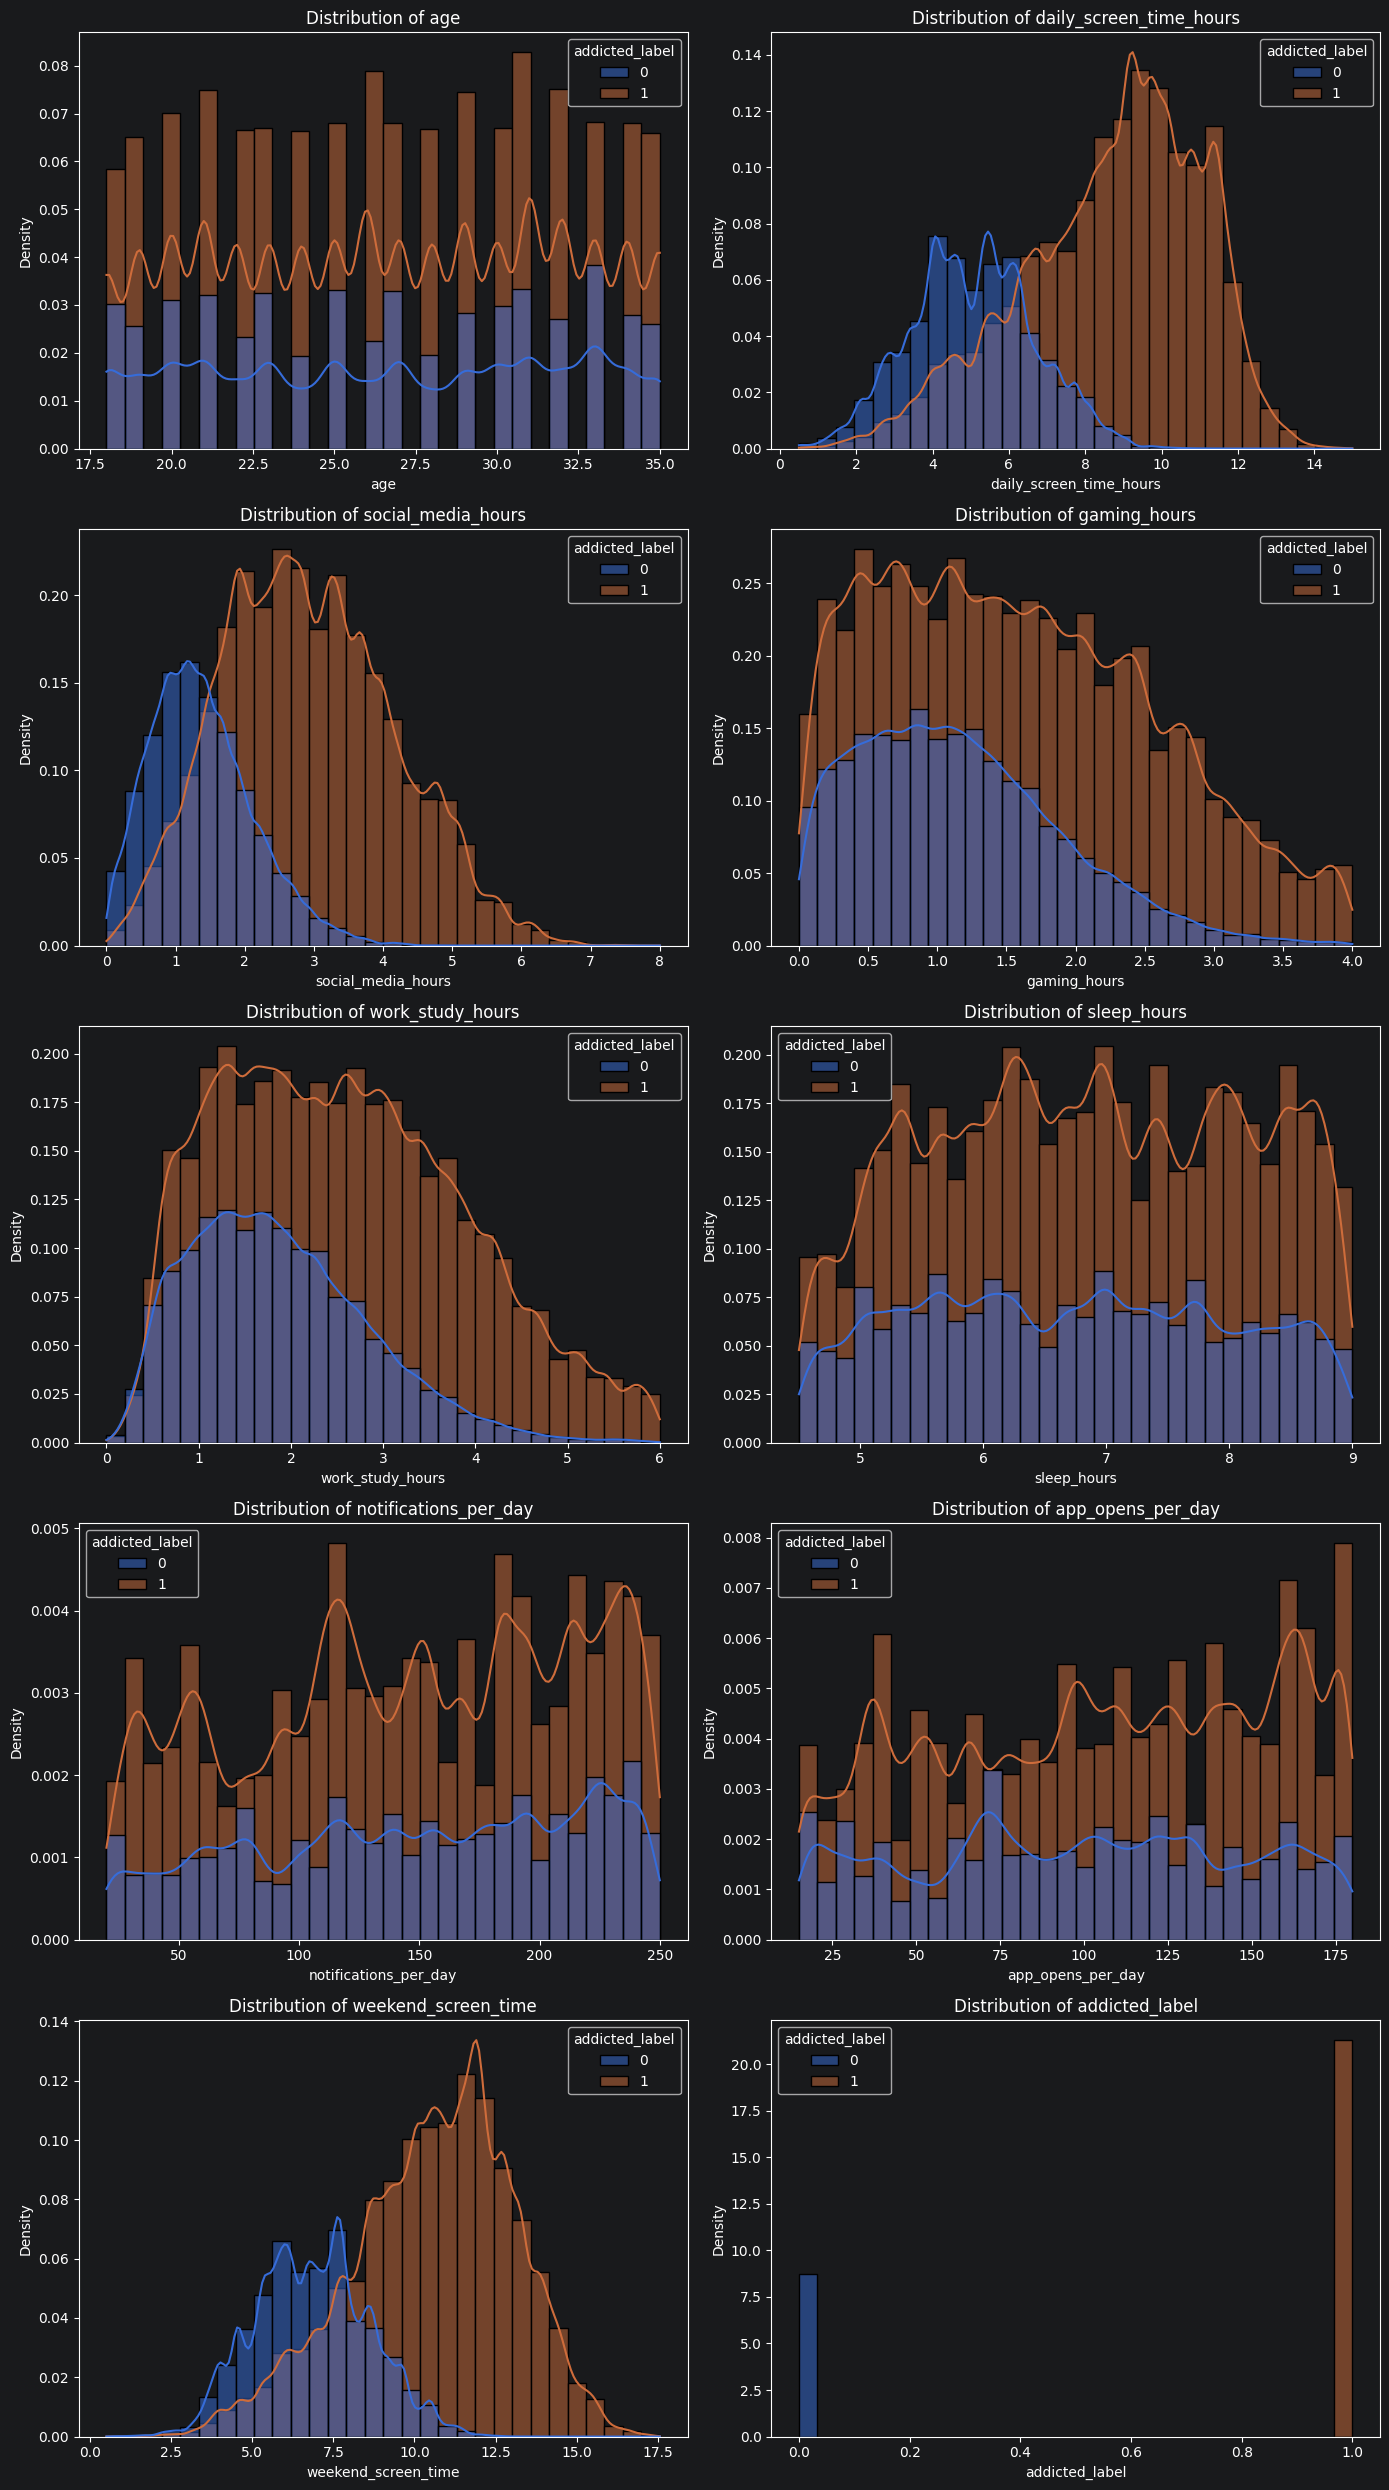

In [8]:
def dist_plots(df, numerical_cols, hue=None, bins=30, kde=True):
    n_cols = 2
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows,n_cols,figsize=(14, 5 * n_rows))

    axes = axes.flatten()

    for ax, col in zip(axes, numerical_cols):
        sns.histplot(data=df,x=col,hue=hue,bins=bins,kde=kde,stat="density",ax=ax)
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")

    # Remove unused axes
    for ax in axes[len(numerical_cols):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

dist_plots(df, numerical_cols, hue="addicted_label")

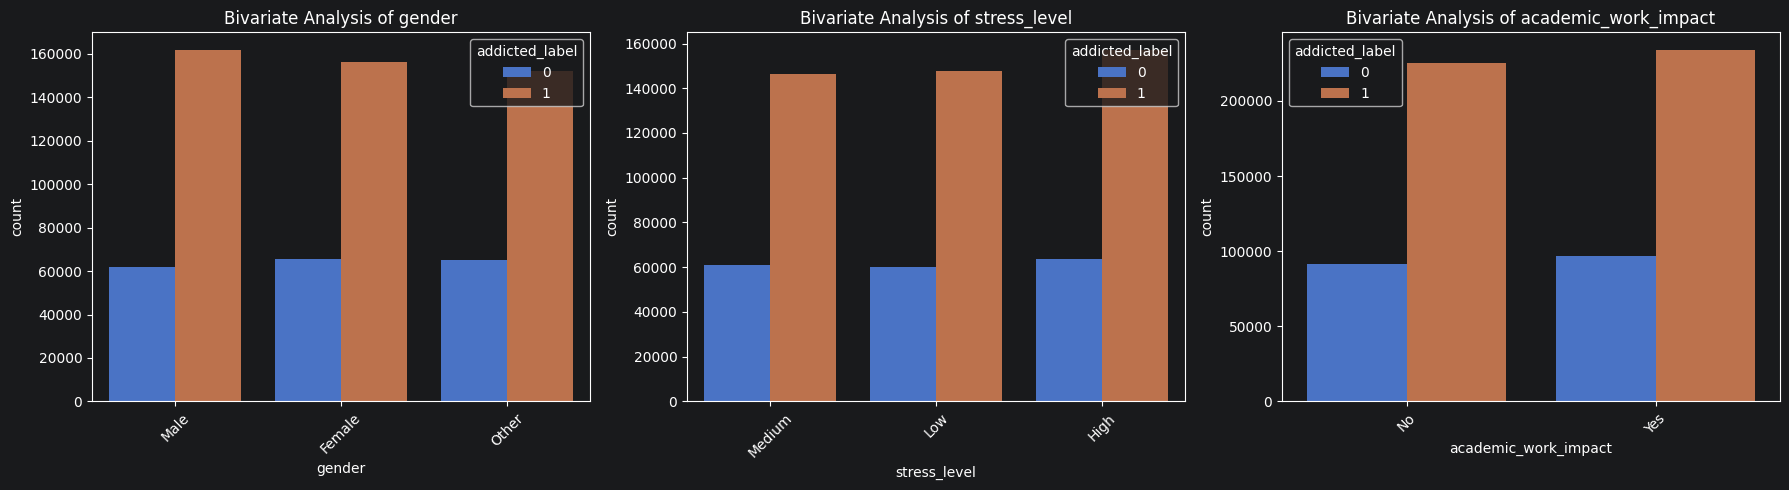

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['gender', 'stress_level', 'academic_work_impact']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue='addicted_label', ax=axes[i])
    axes[i].set_title(f'Bivariate Analysis of {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [9]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

selected_num_cols = [
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "weekend_screen_time"
]

# Features
X = df[selected_num_cols]
y = df["addicted_label"]

# Train/validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

# Validation probabilities
y_prob = xgb_model.predict_proba(X_val)[:, 1]

print("Validation ROC-AUC:", roc_auc_score(y_val, y_prob))

Validation ROC-AUC: 0.9402490991809562


In [11]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

y_pred = xgb_model.predict(X_val)

print('Accuracy:', accuracy_score(y_val, y_pred))
print('\nClassification Report:\n')
print(classification_report(y_val, y_pred))

print('\nFeature Importances:')
importance = xgb_model.feature_importances_
for i, v in enumerate(importance):
    print(f'{selected_num_cols[i]}: {v:.5f}')

Accuracy: 0.8664463311974775

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.74      0.76     40179
           1       0.90      0.92      0.91     98095

    accuracy                           0.87    138274
   macro avg       0.84      0.83      0.84    138274
weighted avg       0.86      0.87      0.87    138274


Feature Importances:
daily_screen_time_hours: 0.45554
social_media_hours: 0.23131
gaming_hours: 0.03639
work_study_hours: 0.03972
weekend_screen_time: 0.23704
